# Shape Assembly: Armadillo → Bunny

Non-growing tissue emulation demo. We sample spheroids from the armadillo mesh
volume (source) and learn GNS update rules that deform them into the bunny
mesh shape (target) using the Chamfer distance loss.

In [1]:
import pyglet
pyglet.options["headless"] = True

import numpy as np
import warp as wp
import torch
import pyvista as pv
from tqdm import trange
from waxmorph.render import PyVistaInterface
import os


pv.set_jupyter_backend("html")

wp.init()
device = "cuda"
torch_device = torch.device("cuda")

np.random.seed(42)
torch.manual_seed(42)

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H100 NVL" (93 GiB, sm_90, mempool enabled)
   Kernel cache:
     /insomnia001/home/ob2391/.cache/warp/1.12.0


## 1. Load meshes and sample point clouds

In [2]:
from waxmorph.data import sample_mesh_pair

N_POINTS = 2000
RADIUS = 0.2
NUM_GENES = 100

data = sample_mesh_pair(
    source_path="meshes/armadillo.ply",
    target_path="meshes/bunny.ply",
    n_points=N_POINTS,
    target_extent=10.0,
    radius=RADIUS,
)

# Poisson disk sampling may yield slightly fewer than requested
print(f"Source: {data['source_pos'].shape}, Target: {data['target_pos'].shape}")

Source: (2000, 3), Target: (2000, 3)


## 2. Initialize Warp state arrays

In [3]:
# Use actual sampled count (Poisson disk may return fewer than requested)
N = len(data["source_pos"])
max_particles = N  # Non-growing: no extra capacity needed

# Positions: start from armadillo
pos_np = data["source_pos"].copy()
X = wp.from_numpy(pos_np.reshape(-1, 3), dtype=wp.vec3f, device=device)

# Radii: uniform
rad_np = np.full(max_particles, RADIUS, dtype=np.float32)
R = wp.from_numpy(rad_np, dtype=wp.float32, device=device)

# Polarities: random unit vectors
rng = np.random.default_rng(42)
pol_np = rng.standard_normal((max_particles, 3)).astype(np.float32)
pol_np /= np.linalg.norm(pol_np, axis=-1, keepdims=True) + 1e-9
P = wp.from_numpy(pol_np, dtype=wp.vec3f, device=device)

# Genes: random initialization
genes_np = rng.random((max_particles, NUM_GENES)).astype(np.float32)
G = wp.from_numpy(genes_np, dtype=wp.float32, device=device)

# Scratch buffer for diffusion Laplacian
lap_G = wp.zeros_like(G)

# Scratch buffer for mechanics gradients
gx = wp.zeros(max_particles, dtype=wp.vec3f, device=device)

# Target positions as torch tensor (may differ in count from source — Chamfer handles this)
X_target = torch.from_numpy(data["target_pos"]).to(torch_device)

print(f"Initialized {N} source particles, {len(data['target_pos'])} target points, {NUM_GENES} genes")

Initialized 2000 source particles, 2000 target points, 100 genes


## 2b. Render initial states (PyVista)

In [ ]:
# Uniform morphogen values (no chemical patterning in shape assembly)
morph_source = np.full(N, 0.5, dtype=np.float32)

# Render source (armadillo)
plotter = PyVistaInterface.draw_3d_view(
    data["source_pos"], rad_np[:N], morph_source, pol_np[:N],
    particle_count=N, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Source (Armadillo)")
plotter.show()


In [ ]:
# Render target (bunny)
N_target = len(data["target_pos"])
morph_target = np.full(N_target, 0.5, dtype=np.float32)
rad_target = np.full(N_target, RADIUS, dtype=np.float32)
pol_target = np.zeros((N_target, 3), dtype=np.float32)
pol_target[:, 2] = 1.0  # dummy polarity

plotter = PyVistaInterface.draw_3d_view(
    data["target_pos"], rad_target, morph_target, pol_target,
    particle_count=N_target, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Target (Bunny)")
plotter.show()


## 3. Build GNS model

In [15]:
from waxmorph.graph import build_graph
from waxmorph.gnn import GNS
from waxmorph.losses import chamfer_distance, squared_loss, make_samples_loss

# Probe feature dimensions from one graph build (no CT for single-tissue emulation)
node_feats, edge_index, edge_feats = build_graph(X, P, R, particle_count=N, G=G)

print(f"Node features: {node_feats.shape}  ({NUM_GENES} genes = {node_feats.shape[1]})")
print(f"Edge index: {edge_index.shape}  ({edge_index.shape[1]} directed edges)")
print(f"Edge features: {edge_feats.shape}")

model = GNS(
    node_feature_dim=node_feats.shape[1],
    edge_feature_dim=edge_feats.shape[1],
    node_latent_dim=256,
    edge_latent_dim=256,
    hidden_dim=256,
    num_mp_steps=5,
    num_mlp_layers=2,
    output_dims={"dX": 3, "dP": 3, "dG": NUM_GENES},
    checkpoint_processor=True,
).to(torch_device)

n_params = sum(p.numel() for p in model.parameters())
print(f"GNS parameters: {n_params:,}")

# Loss function — swap loss type here (sinkhorn, hausdorff, energy, gaussian, laplacian)
loss_fn = make_samples_loss(loss="sinkhorn")

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

losses, losses_shape, losses_l2 = [], [], []

# Best-trajectory tracking
best_loss = float("inf")
best_model_state = None
best_trajectory = None

Node features: torch.Size([2000, 100])  (100 genes = 100)
Edge index: torch.Size([2, 8426])  (8426 directed edges)
Edge features: torch.Size([8426, 2])
GNS parameters: 2,687,850


## 4. Training loop

In [5]:
import copy
from waxmorph.emulator import mech_step_sticky, diffusion_step

N_EPOCHS = 1000     # Training epochs

if os.path.exists('runs/armadillo_bunny.pt'):
    model = GNS.load("runs/armadillo_bunny.pt").cuda()
    N_EPOCHS = 1


T_ROLLOUT = 100      # Number of GNS steps per training iteration
MECH_STEPS = 5       # Mechanics relaxation steps after each GNS update
DIFF_STEPS = 5       # Diffusion steps per GNS step
DT_MECH = 1e-2       # Mechanics time step
DT_DIFF = 1e-2       # Diffusion time step
ALPHA_DIFF = 0.1     # Diffusion coefficient
L2_LAMBDA = 1e-3     # L2 regularization for actions

# Velocity integration parameters
DT_GNS = 1e-2         # Time step for GNS velocity integration (Euler step)

for epoch in trange(N_EPOCHS):
    optimizer.zero_grad()

    # Reset full state to initial conditions each epoch
    X_current = wp.from_numpy(pos_np.copy(), dtype=wp.vec3f, device=device)
    G_current = wp.from_numpy(genes_np.copy(), dtype=wp.float32, device=device)
    P_current = wp.from_numpy(pol_np.copy(), dtype=wp.vec3f, device=device)

    # Accumulate GNS-predicted displacements (for gradient flow)
    total_dX = torch.zeros(N, 3, device=torch_device)
    epoch_trajectory = [pos_np.copy()]

    loss_l2 = torch.tensor(0., requires_grad=True)

    for t in range(T_ROLLOUT):
        # Build graph from current Warp state
        node_feats, edge_index, edge_feats = build_graph(
            X_current, P_current, R, particle_count=N, G=G_current,
        )

        # GNS forward — outputs are time derivatives (velocities)
        out = model(node_feats, edge_index, edge_feats)

        # --- dX: position velocity, clamped and integrated ---
        dX = out["dX"] * DT_GNS
        total_dX = total_dX + dX

        # --- dP: polarity velocity, integrated + renormalized ---
        dP = out["dP"] * DT_GNS

        # --- dG: gene velocity, integrated (diffusion added below) ---
        dG = out["dG"] * DT_GNS

        # Add to l2 loss
        loss_l2 = loss_l2 +  dX.square().sum()
        loss_l2 = loss_l2 + dP.square().sum()
        loss_l2 = loss_l2 + dG.square().sum()

        # Apply all predicted updates to Warp state (detached, for next step's graph)
        dX_np = dX.detach().cpu().numpy()
        dP_np = dP.detach().cpu().numpy()
        dG_np = dG.detach().cpu().numpy()

        # Update positions: X(t+dt) = X(t) + dX
        x_np = X_current.numpy()
        x_np[:N] += dX_np
        X_current = wp.from_numpy(x_np, dtype=wp.vec3f, device=device)

        # Update polarities: P(t+dt) = normalize(P(t) + dP)
        p_np = P_current.numpy()
        p_np[:N] += dP_np
        p_norms = np.linalg.norm(p_np[:N], axis=-1, keepdims=True)
        p_np[:N] /= np.maximum(p_norms, 1e-9)
        P_current = wp.from_numpy(p_np, dtype=wp.vec3f, device=device)

        # Update genes: G(t+dt) = G(t) + dG (diffusion added below)
        g_np = G_current.numpy()
        g_np[:N] += dG_np
        G_current = wp.from_numpy(g_np, dtype=wp.float32, device=device)

        # Mechanics relaxation (applies sticky-sphere potential gradient to X)
        for _ in range(MECH_STEPS):
            mech_step_sticky(X_current, R, N, DT_MECH, gx)

        # Gene diffusion: alpha * laplacian(G)
        for _ in range(DIFF_STEPS):
            diffusion_step(X_current, R, G_current, lap_G, N, ALPHA_DIFF, DT_DIFF)

        epoch_trajectory.append(X_current.numpy()[:N].copy())

    # Compute loss: predicted final positions vs target
    X_source_t = torch.from_numpy(data["source_pos"]).to(torch_device)
    X_pred = X_source_t + total_dX
    loss_shape = loss_fn(X_pred, X_target)
    loss = loss_shape + (loss_l2 * L2_LAMBDA)

    loss.backward()
    optimizer.step()

    epoch_loss = loss.item()
    epoch_shape_loss = loss_shape.item()
    epoch_l2_loss = loss_l2.item()
    
    losses.append(epoch_loss)
    losses_shape.append(epoch_shape_loss)
    losses_l2.append(epoch_l2_loss)

    # Track best
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_shape_loss = epoch_shape_loss
        best_l2_loss = epoch_l2_loss 
        best_model_state = copy.deepcopy(model.state_dict())
        best_trajectory = epoch_trajectory

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:4d}/{N_EPOCHS}  best={best_loss:.4f}  best_shape_loss={best_shape_loss:.4f}  best_l2_loss={best_l2_loss:.4f}")

# Restore best model
model.load_state_dict(best_model_state)

# Save to disk
if not os.path.exists('runs/armadillo_bunny.pt'):
    model.save("runs/armadillo_bunny.pt")

  0%|                                                                                          | 0/1000 [00:00<?, ?it/s]

Module waxmorph.emulator a238c57 load on device 'cuda:0' took 1836.78 ms  (compiled)


  1%|▊                                                                                | 10/1000 [00:23<35:23,  2.14s/it]

Epoch   10/1000  best=1.5333  best_shape_loss=1.3997  best_l2_loss=133.5914


  2%|█▌                                                                               | 20/1000 [00:44<34:59,  2.14s/it]

...

Epoch  980/1000  best=0.1918  best_shape_loss=0.0183  best_l2_loss=173.4735


 99%|███████████████████████████████████████████████████████████████████████████████▏| 990/1000 [33:52<00:20,  2.05s/it]

Epoch  990/1000  best=0.1918  best_shape_loss=0.0183  best_l2_loss=173.4735


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [34:13<00:00,  2.05s/it]

Epoch 1000/1000  best=0.1918  best_shape_loss=0.0183  best_l2_loss=173.4735


## 5. Visualize loss curve

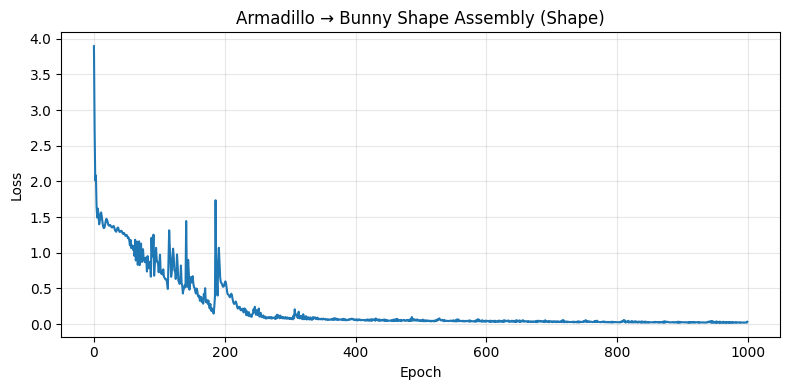

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses_shape)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Armadillo → Bunny Shape Assembly (Shape)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

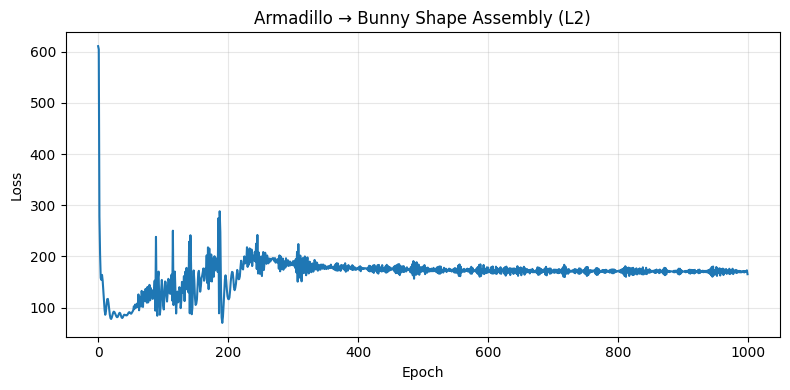

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses_l2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Armadillo → Bunny Shape Assembly (L2)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

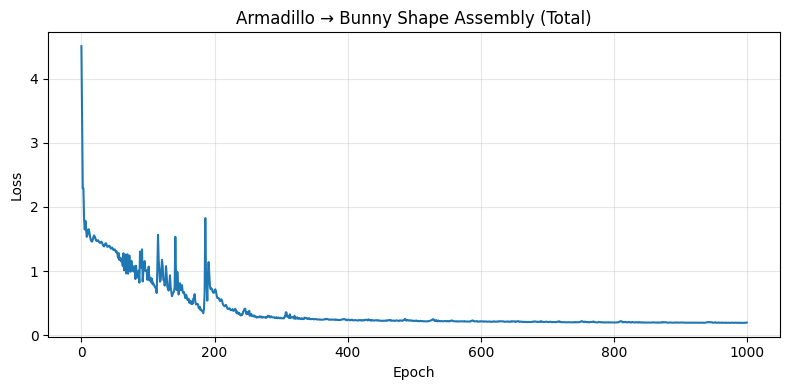

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Armadillo → Bunny Shape Assembly (Total)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Final rollout with trajectory capture

In [9]:
# Use the best trajectory captured during training
trajectory = best_trajectory
X_final = trajectory[-1]
print(f"Using best trajectory ({len(trajectory)} frames, best loss={best_loss:.4f})")

Using best trajectory (101 frames, best loss=0.1918)


## 7. Render final state (PyVista)

In [10]:
morph_final = np.full(N, 0.5, dtype=np.float32)

plotter = PyVistaInterface.draw_3d_view(
    X_final, rad_np[:N], morph_final, pol_np[:N],
    particle_count=N, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Predicted (Final)")
plotter.show()


2026-03-16 13:24:29.977 (2093.959s) [    1502225D1740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## 8. Deformation movie (WarpMovieRenderer)

In [11]:
import os
from waxmorph.render import WarpMovieRenderer

os.makedirs("Output", exist_ok=True)
VIDEO_PATH = "Output/shape_assembly.usd"

# Interpolate between trajectory keyframes for smoother video
# Should be used very carefully, can misrepresent results!
# Shouldn't change from 1 unless you know what this is doing 
INTERP_STEPS = 4

# Use uniform light blue coloring
colors_rgb = np.full((N, 3), [0.3, 0.6, 0.9], dtype=np.float32)

with WarpMovieRenderer(
    filename=VIDEO_PATH,
    max_particles=N,
    width=1920,
    height=1080,
    fps=30,
    device="cuda",
) as mov:
    frame_idx = 0
    for seg in trange(len(trajectory) - 1):
        start = trajectory[seg]
        end = trajectory[seg + 1]
        for sub in range(INTERP_STEPS):
            alpha = sub / INTERP_STEPS
            s = 3.0 * alpha**2 - 2.0 * alpha**3   # cubic interpolation
            pts = start * (1.0 - s) + end * s
            mov.write_frame_from_numpy(
                t=float(frame_idx),
                centers=pts,
                radii=rad_np[:N],
                colors=colors_rgb,
                particle_count=N,
            )
            frame_idx += 1
    # Write final frame a few extra times
    for _ in trange(15):
        mov.write_frame_from_numpy(
            t=float(frame_idx),
            centers=trajectory[-1],
            radii=rad_np[:N],
            colors=colors_rgb,
            particle_count=N,
        )
        frame_idx += 1

100%|█████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 1990.59it/s]

Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/shape_assembly.usd`
